## Linear Regression HW 2 - Lokesh Muvva

Answers to all the coding questions are at the very end.

In [1]:
import numpy as np
import pandas as pd
from plotnine import (
    aes,
    geom_hline,
    geom_line,
    geom_point,
    geom_segment,
    geom_smooth,
    ggplot,
    ggtitle,
    labs,
    theme_minimal,
    xlab,
    ylab
)
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# Read CSV file
infections = pd.read_csv(
    "/Users/lokeshmuvva/Documents/regression_f25/data/hospital_infection.csv"
)

# Display the first few rows
print(infections.head())

   ID   Stay   Age  InfctRsk  Culture   Xray  Beds  MedSchool  Region  Census  \
0   5  11.20  56.5       5.7     34.5   88.9   180          2       1     134   
1  10   8.84  56.3       6.3     29.6   82.6    85          2       1      59   
2  11  11.07  53.2       4.9     28.5  122.0   768          1       1     591   
3  13  12.78  56.8       7.7     46.0  116.9   322          1       1     252   
4  18  11.62  53.9       6.4     25.5   99.2   133          2       1     113   

   Nurses  Facilities  
0     151        40.0  
1      66        40.0  
2     656        80.0  
3     349        57.1  
4     101        37.1  


In [3]:
infections_reg = infections.drop(
    columns=[
        'ID', 'Age', 'Culture', 'Xray', 'Beds', 'MedSchool', 
        'Region', 'Census', 'Nurses', 'Facilities'
    ]
)

In [4]:
# Summary statistics for Stay
print(infections_reg['Stay'].describe())

count    58.00000
mean     10.04931
std       1.44107
min       7.39000
25%       8.90500
50%       9.93000
75%      11.06000
max      13.95000
Name: Stay, dtype: float64


In [5]:
# Summary statistics for InfctRsk
print(infections_reg['InfctRsk'].describe())

count    58.000000
mean      4.556897
std       1.305066
min       1.300000
25%       3.900000
50%       4.500000
75%       5.300000
max       7.800000
Name: InfctRsk, dtype: float64


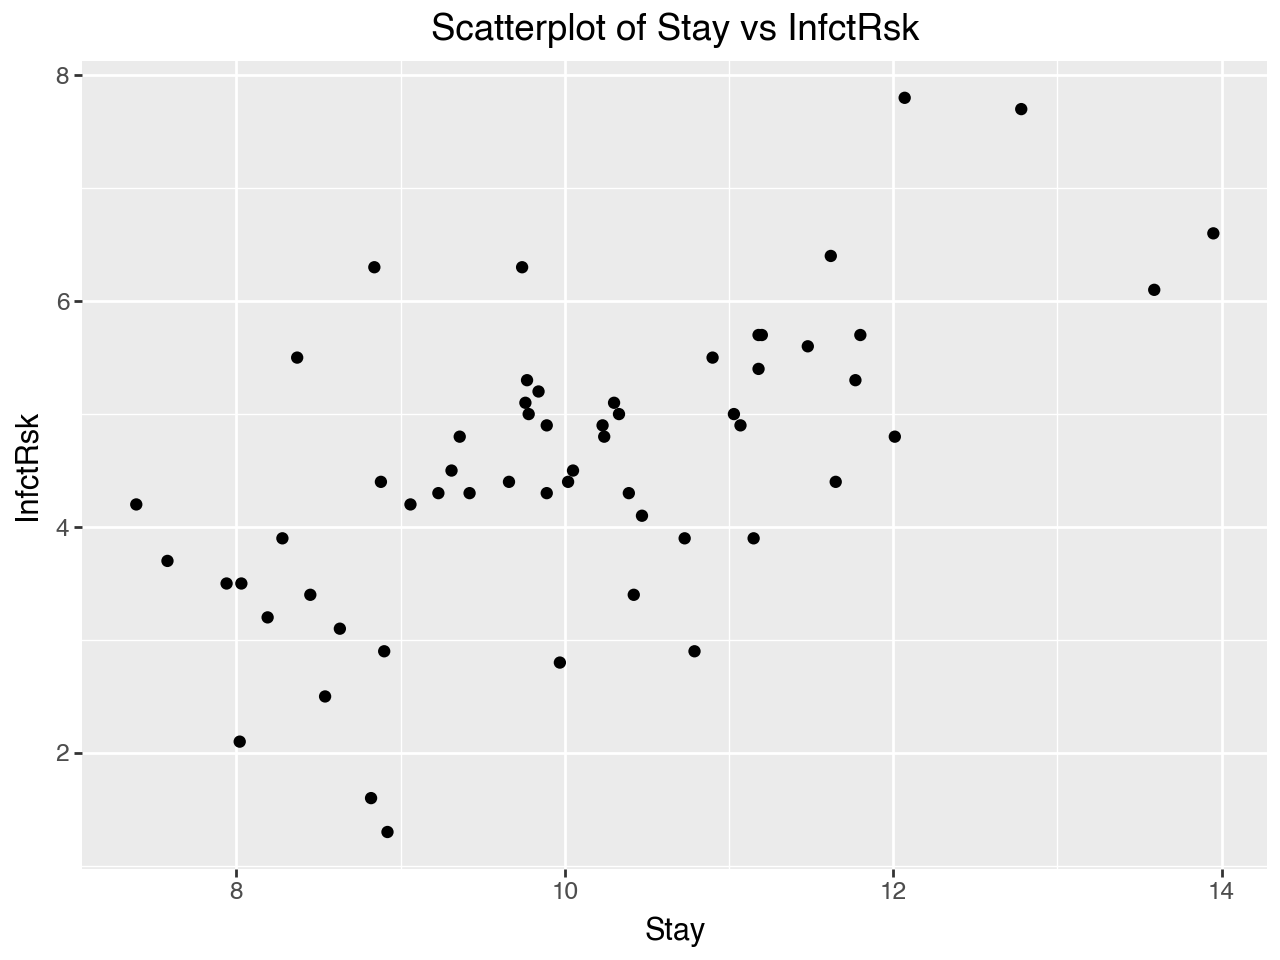

In [6]:
# Create scatterplot of Stay vs InfctRsk
(
    ggplot(infections_reg, aes(x='Stay', y='InfctRsk')) +
    geom_point() +
    labs(
        title='Scatterplot of Stay vs InfctRsk',
        x='Stay',
        y='InfctRsk'
    )
)

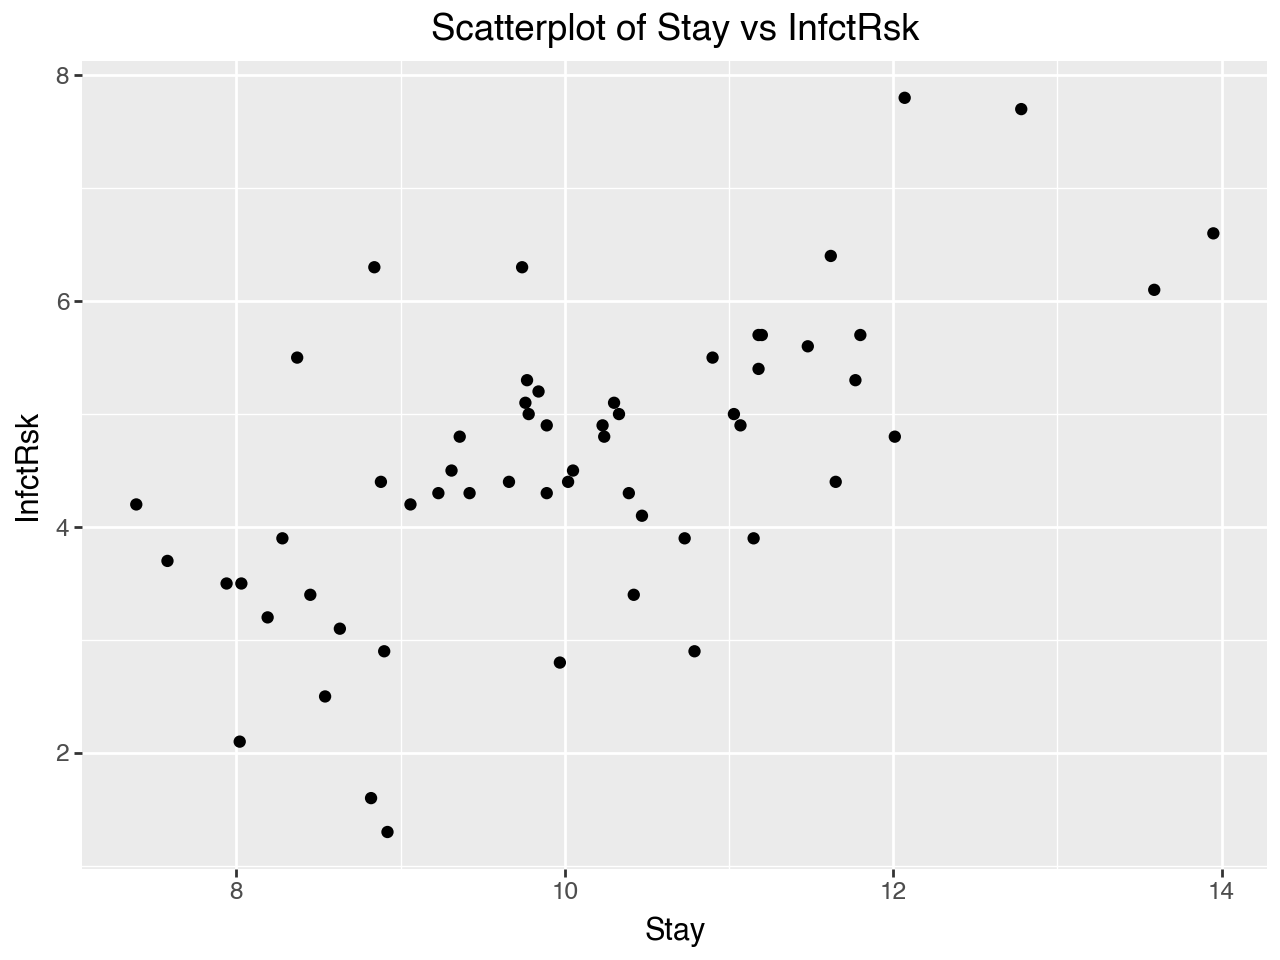

In [7]:
# Create scatter plot
# Define dataframe, x variable, and y variable
# Use scatterplot to visualize relationship
# Label axes with descriptive names
plot1 = (
    ggplot(infections_reg, aes(x='Stay', y='InfctRsk')) +
    geom_point() +
    labs(
        title='Scatterplot of Stay vs InfctRsk',
        x='Stay',
        y='InfctRsk'
    )
)

# Display the plot
plot1

In [8]:
# Correlation
correlation = infections_reg['Stay'].corr(infections_reg['InfctRsk'])
print("Correlation:", correlation)

Correlation: 0.6281495283832491


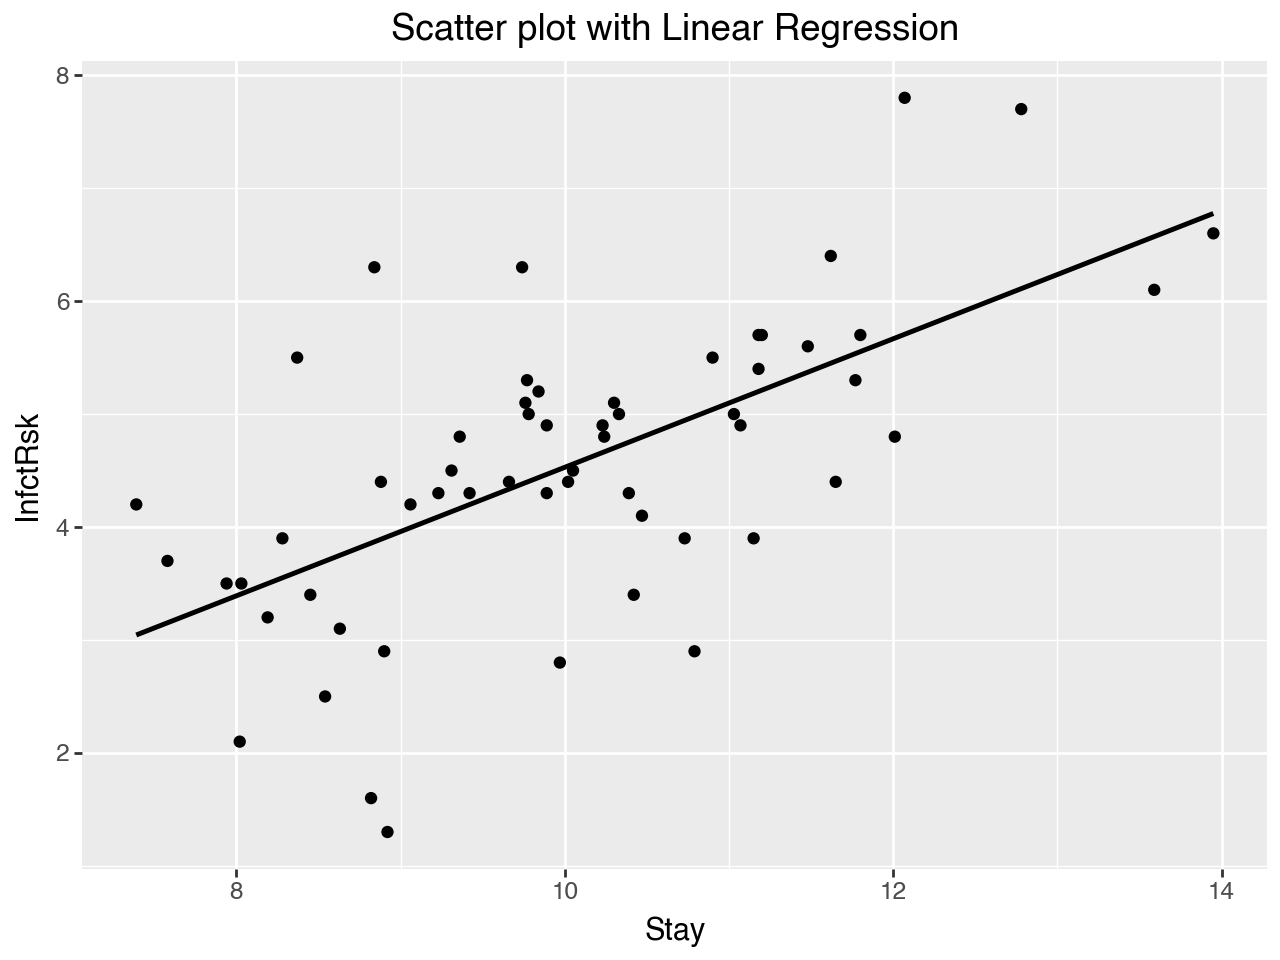

In [9]:
# Scatter plot with linear regression line
plot3 = (
    ggplot(infections_reg, aes(x='Stay', y='InfctRsk')) +
    geom_point() +
    geom_smooth(method='lm', formula='y ~ x', se=False) +
    labs(
        title='Scatter plot with Linear Regression',
        x='Stay',
        y='InfctRsk'
    )
)

# Display the plot
plot3

In [10]:
# Fit linear model
X = infections_reg[['Stay']]
y = infections_reg[['InfctRsk']]
model = LinearRegression().fit(X, y)

In [11]:
model.intercept_, model.coef_

(array([-1.15981903]), array([[0.56886646]]))

In [12]:
# Linear model summary
slope = model.coef_[0]
intercept = model.intercept_
print(f"Slope: {slope}, Intercept: {intercept}")

Slope: [0.56886646], Intercept: [-1.15981903]


In [13]:
infections_reg.head()

,Stay,InfctRsk
0,11.20,5.7
1,8.84,6.3
2,11.07,4.9
3,12.78,7.7
4,11.62,6.4


In [14]:
# Predicted values and residuals -- add to DataFrame
infections_reg.loc[:, 'Predicted'] = model.predict(X)
infections_reg.loc[:, 'Residuals'] = (
    infections_reg['InfctRsk'] - infections_reg['Predicted']
)

In [15]:
infections_reg.head()

,Stay,InfctRsk,Predicted,Residuals
0,11.20,5.7,5.211485,0.488515
1,8.84,6.3,3.868960,2.431040
2,11.07,4.9,5.137533,-0.237533
3,12.78,7.7,6.110294,1.589706
4,11.62,6.4,5.450409,0.949591


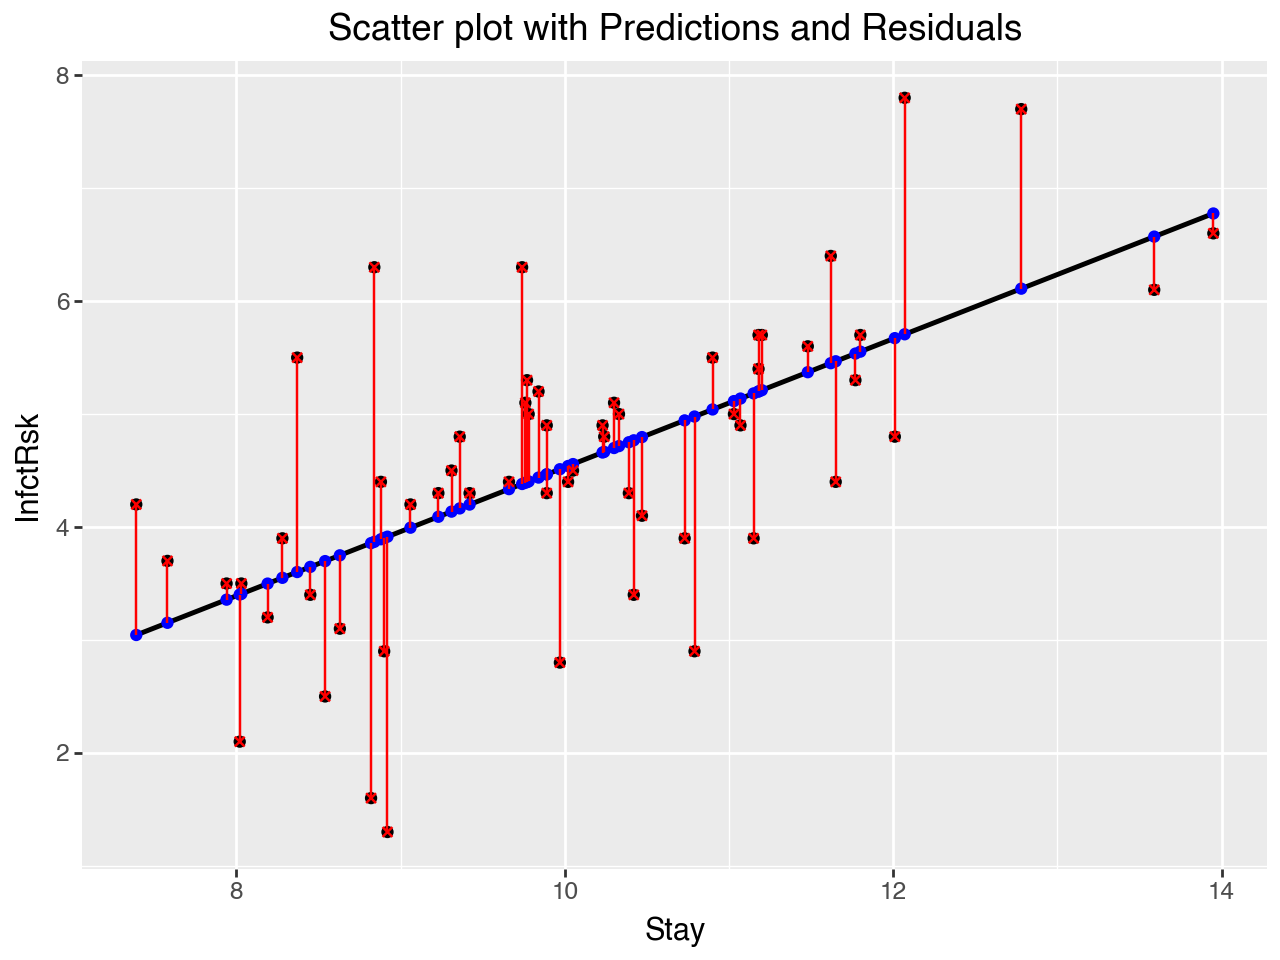

In [16]:
# Scatter plot with predicted values and residuals
plot4 = (
    ggplot(infections_reg, aes(x='Stay', y='InfctRsk')) +
    geom_point() +
    geom_smooth(method='lm', formula='y ~ x', se=False) +
    geom_point(aes(y='Predicted'), shape='o', color='blue') +
    labs(
        title='Scatter plot with Predictions and Residuals',
        x='Stay',
        y='InfctRsk'
    ) +
    geom_point(aes(y='InfctRsk'), shape='x', color='red') +
    geom_segment(aes(xend='Stay', yend='Predicted'), color='red')
)

# Display the plot
plot4

In [17]:
# Calculate predicted infection risk for a specific stay length
stay = 32
predicted_infct_rsk = intercept + slope * stay
print(
    f"Predicted infection risk for a hospital with an average stay length "
    f"of {stay} days: {predicted_infct_rsk}"
)

Predicted infection risk for a hospital with an average stay length of 32 days: [17.04390764]


In [18]:
# Alternative prediction using the model
new_stay = pd.DataFrame({'Stay': [32]})
pred = model.predict(new_stay)
print(
    "Predicted infection risk for a hospital with an average stay length "
    f"of 32 days: {pred}"
)

Predicted infection risk for a hospital with an average stay length of 32 days: [[17.04390764]]


In [19]:
# Fit OLS regression model using formula interface
# Formula syntax: 'y~x' for simple regression or 'y~x1+x2+x3..' for multiple
model = smf.ols('InfctRsk ~ Stay', infections).fit()

# Display model summary with statistics and diagnostics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               InfctRsk   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     36.50
Date:                Sun, 07 Sep 2025   Prob (F-statistic):           1.30e-07
Time:                        23:13:59   Log-Likelihood:                -82.684
No. Observations:                  58   AIC:                             169.4
Df Residuals:                      56   BIC:                             173.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1598      0.956     -1.213      0.230      -3.075       0.755
Stay           0.5689      0.094      6.041      0.000       0.380       0.757
==============================================================================
Omnibus:                        1.579   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.454   Jarque-Bera (JB):                0.839
Skew:                          -0.170   Prob(JB):                        0.657
Kurtosis:                       3.481   Cond. No.                         72.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
# Extract MSE
model.mse_resid

np.float64(1.0495772095890705)

In [21]:
# Find SSX = sum(Xi-X_bar)^2
SSX=np.sum((infections.Stay-np.mean(infections.Stay))**2) # Sum(Xi-X_bar)^2
SSX

np.float64(118.37097241379311)

In [22]:
# Calculate se
se_beta_1 = np.sqrt(model.mse_resid/SSX)
se_beta_1

np.float64(0.09416393270461956)

In [23]:
print(model.params)

Intercept   -1.159819
Stay         0.568866
dtype: float64


In [24]:
t = model.params.iloc[1]/se_beta_1
t

np.float64(6.0412351324499385)

In [25]:
aov_table = sm.stats.anova_lm(model, typ=1)
aov_table

# We will explain the 'typ' argument later in MLR. It doesn't matter in SLR.

,df,sum_sq,mean_sq,F,PR(>F)
Stay,1.0,38.305918,38.305918,36.496522,1.302453e-07
Residual,56.0,58.776324,1.049577,NaN,NaN


In [26]:
fitted = model.predict(infections.Stay)
fitted

0     5.211485
1     3.868960
2     5.137533
3     6.110294
4     5.450409
5     4.403695
6     4.136328
7     3.499197
8     5.467475
9     5.114778
10    5.535739
11    6.571076
12    4.716571
13    5.370768
14    3.749499
15    5.183042
16    4.767769
17    4.198903
18    3.408179
19    4.557289
20    3.903092
21    4.164771
22    3.698301
23    5.672267
24    4.466270
25    6.775868
26    3.857583
27    4.392318
28    5.200108
29    3.152189
30    3.994111
31    4.665374
32    3.550395
33    4.466270
34    4.437827
35    4.380940
36    4.511780
37    4.796213
38    3.601593
39    5.040825
40    4.090818
41    5.706399
42    4.944118
43    5.200108
44    4.335431
45    4.540223
46    3.044104
47    3.647103
48    4.659685
49    3.891715
50    4.699505
51    4.978250
52    3.356981
53    4.750703
54    3.914470
55    4.398006
56    3.402490
57    5.552805
dtype: float64

In [27]:
# Get prediction with confidence and prediction intervals
prediction = model.get_prediction(exog=dict(Stay=new_stay.Stay))

# Display prediction summary with 95% confidence intervals (alpha=0.05)
prediction.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,17.043908,2.071336,12.894523,21.193292,12.414726,21.673089


In [28]:
from scipy.stats import f


def ss_decomp(X, y):
    """
    Perform sum of squares decomposition for linear regression.
    
    Parameters:
    -----------
    X : array-like
        Independent variable(s)
    y : array-like
        Dependent variable
        
    Returns:
    --------
    tuple
        Two ggplot objects showing SST and SSR/SSE decomposition
    """
    # Fit a linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Make predictions
    y_pred = model.predict(X)

    # Calculate the mean of y
    y_mean = np.mean(y)
    n = len(y)

    # Calculate SS quantities
    SST = np.sum((y - y_mean) ** 2).round(4)
    SSR = np.sum((y_pred - y_mean) ** 2).round(4)
    SSE = np.sum((y - y_pred) ** 2).round(4)

    # Output the sum of squares decomposition
    print(f"SST (Total Sum of Squares): {SST.item()}")
    print(f"SSR (Regression Sum of Squares): {SSR.item()}")
    print(f"SSE (Error Sum of Squares): {SSE.item()}")
    print(
        f"SST = SSR + SSE: "
        f"{np.isclose(SST.item(), SSR.item() + SSE.item())}"
    )
    
    r_squared = np.round(1 - SSE.item() / SST.item(), 4)
    print(f"Coefficient of Determination, R^2 is: {r_squared}")

    # Calculate F-statistic
    f_stat = (SSR.item() / 1) / (SSE.item() / (n - 2))

    # Calculate critical F-value
    alpha = 0.05
    df1 = 1
    df2 = n - 2
    f_crit = f.ppf(1 - alpha, df1, df2)

    print(f"The F-Statistic is: {f_stat}")
    print(f"The Critical F-Value (alpha = 0.05) is: {f_crit}")

    if f_stat > f_crit:
        print(
            "We reject the null hypothesis that the slope = 0. "
            "X is a significant predictor of Y"
        )
    else:
        print(
            "We fail to reject the null hypothesis. "
            "X is not a significant predictor of Y"
        )
    
    # Create DataFrame for plotting
    df = pd.DataFrame({
        'X': X.squeeze(),
        'y': y.squeeze(),
        'predicted': y_pred.flatten(),
        'y_mean': y_mean
    })

    # Plot 1: Show SST components (deviations from mean)
    gg1 = (
        ggplot(df, aes(x='X', y='y')) + 
        geom_point() + 
        geom_hline(yintercept=y_mean, linetype='dashed') + 
        geom_segment(
            aes(xend='X', yend='y_mean'), 
            color='black'
        ) +  # SST components
        ggtitle(f"SST Decomposition - R^2 is {r_squared}")
    )
    
    # Plot 2: Show SSR and SSE components
    gg2 = (
        ggplot(df, aes(x='X', y='y')) + 
        geom_point() + 
        geom_smooth(method='lm', formula='y ~ x', se=False) +
        geom_hline(yintercept=y_mean, linetype='dashed') + 
        geom_segment(
            aes(xend='X', y='predicted', yend='y_mean'), 
            color='blue', 
            linetype='dashed'
        ) +  # SSR components 
        geom_segment(
            aes(xend='X', yend='predicted'), 
            color='red', 
            linetype='dashed'
        ) +  # SSE components
        ggtitle(f"SSR/SSE Decomposition - R^2 is {r_squared}")
    )

    # Return the plot objects
    return gg1, gg2

SST (Total Sum of Squares): 97.0822
SSR (Regression Sum of Squares): 38.3059
SSE (Error Sum of Squares): 58.7763
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.3946
The F-Statistic is: 36.496519855792215
The Critical F-Value (alpha = 0.05) is: 4.012973377650136
We reject the null hypothesis that the slope = 0. X is a significant predictor of Y


/Users/lokeshmuvva/Documents/Temp/ENV/linreg/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
/Users/lokeshmuvva/Documents/Temp/ENV/linreg/lib/python3.9/site-packages/IPython/lib/pretty.py:778: FutureWarning: Using repr(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


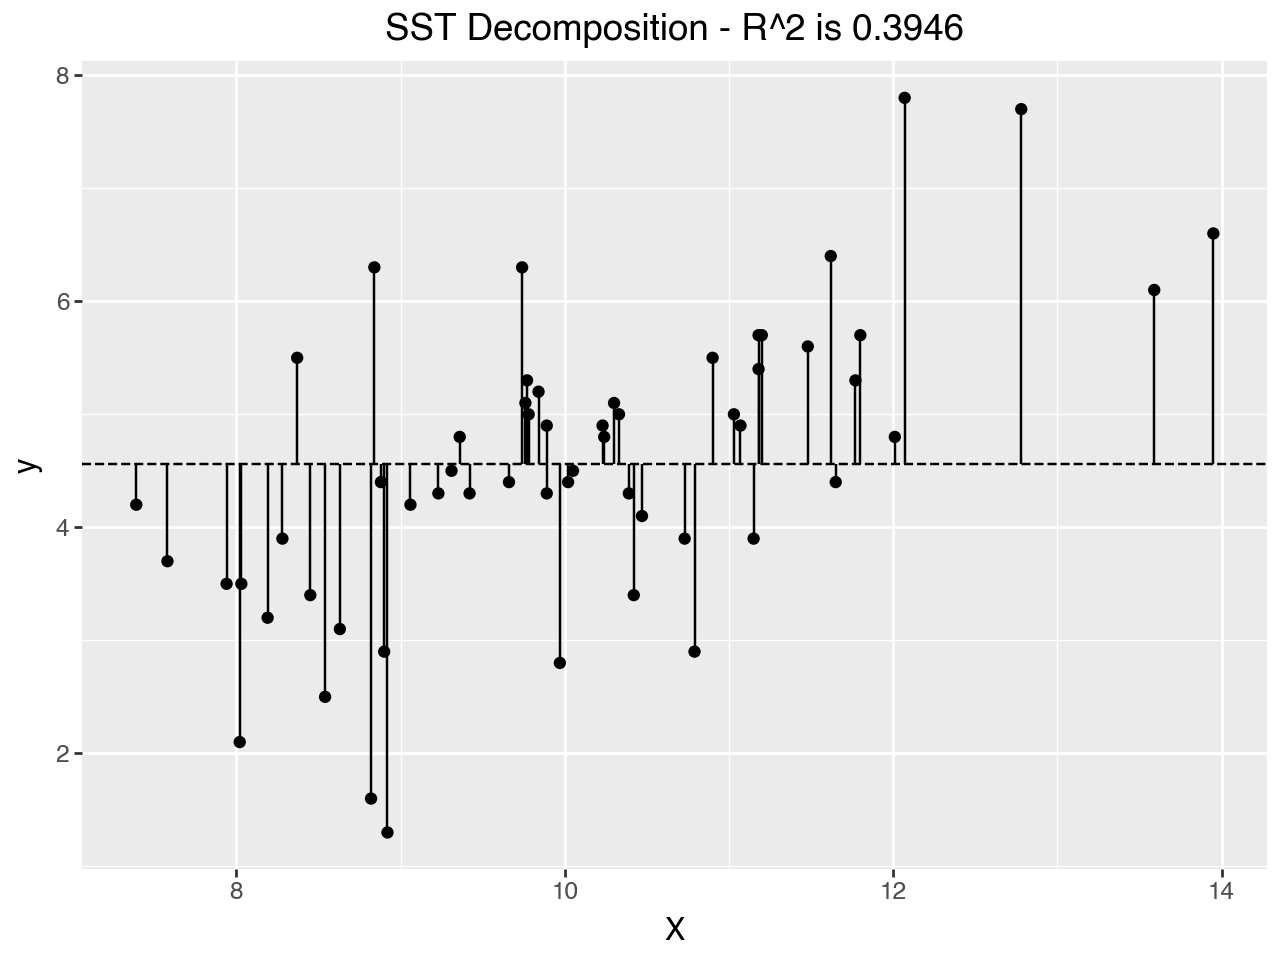

/Users/lokeshmuvva/Documents/Temp/ENV/linreg/lib/python3.9/site-packages/IPython/lib/pretty.py:778: FutureWarning: Using repr(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


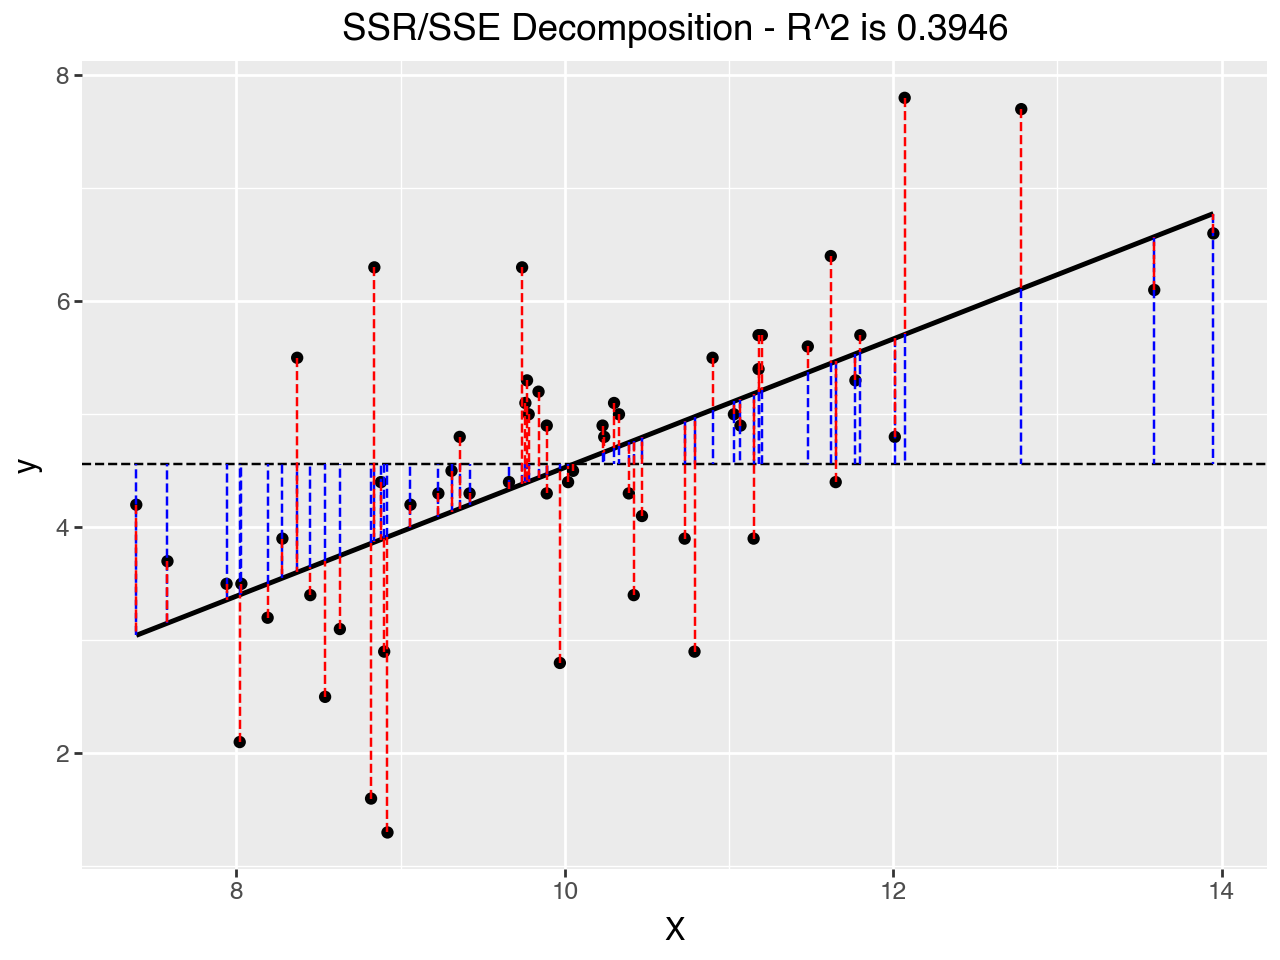

(<Figure Size: (640 x 480)>, <Figure Size: (640 x 480)>)

In [29]:
ss_decomp(X, y)

In [30]:
infections_reg.shape

(58, 4)

In [31]:
print(list(infections_reg.columns))

['Stay', 'InfctRsk', 'Predicted', 'Residuals']


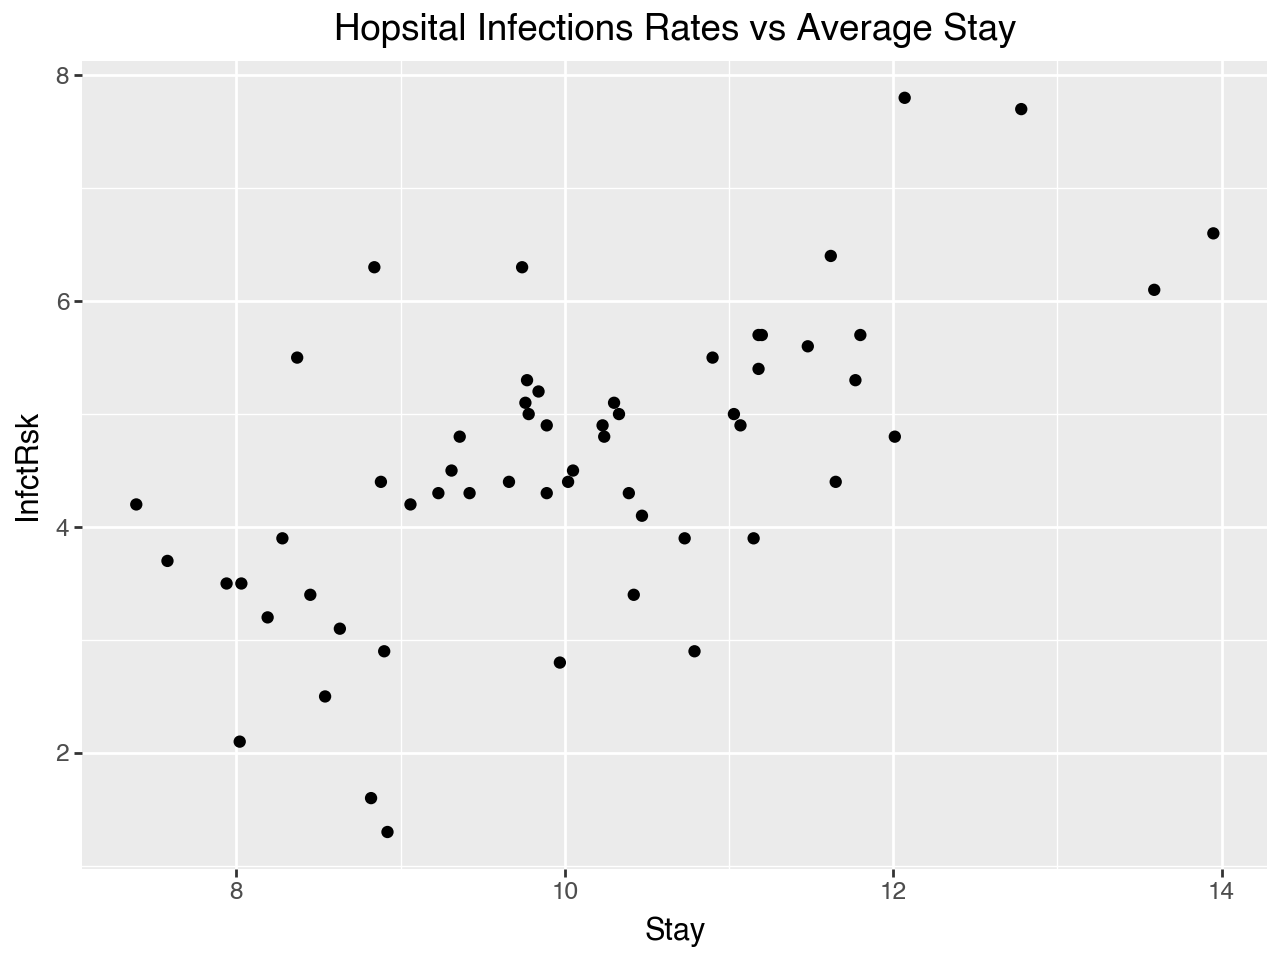

In [32]:
plot_bos = (
    ggplot(infections_reg, aes(x='Stay', y='InfctRsk')) +
    geom_point() +
    labs(title='Hopsital Infections Rates vs Average Stay', x='Stay', y='InfctRsk')
)
plot_bos

In [33]:
# Fit a model
import statsmodels.formula.api as smf
model = smf.ols('InfctRsk ~ Stay', infections_reg).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               InfctRsk   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     36.50
Date:                Sun, 07 Sep 2025   Prob (F-statistic):           1.30e-07
Time:                        23:13:59   Log-Likelihood:                -82.684
No. Observations:                  58   AIC:                             169.4
Df Residuals:                      56   BIC:                             173.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1598      0.956     -1.213      0.230      -3.075       0.755
Stay           0.5689      0.094      6.041      0.000       0.380       0.757
==============================================================================
Omnibus:                        1.579   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.454   Jarque-Bera (JB):                0.839
Skew:                          -0.170   Prob(JB):                        0.657
Kurtosis:                       3.481   Cond. No.                         72.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

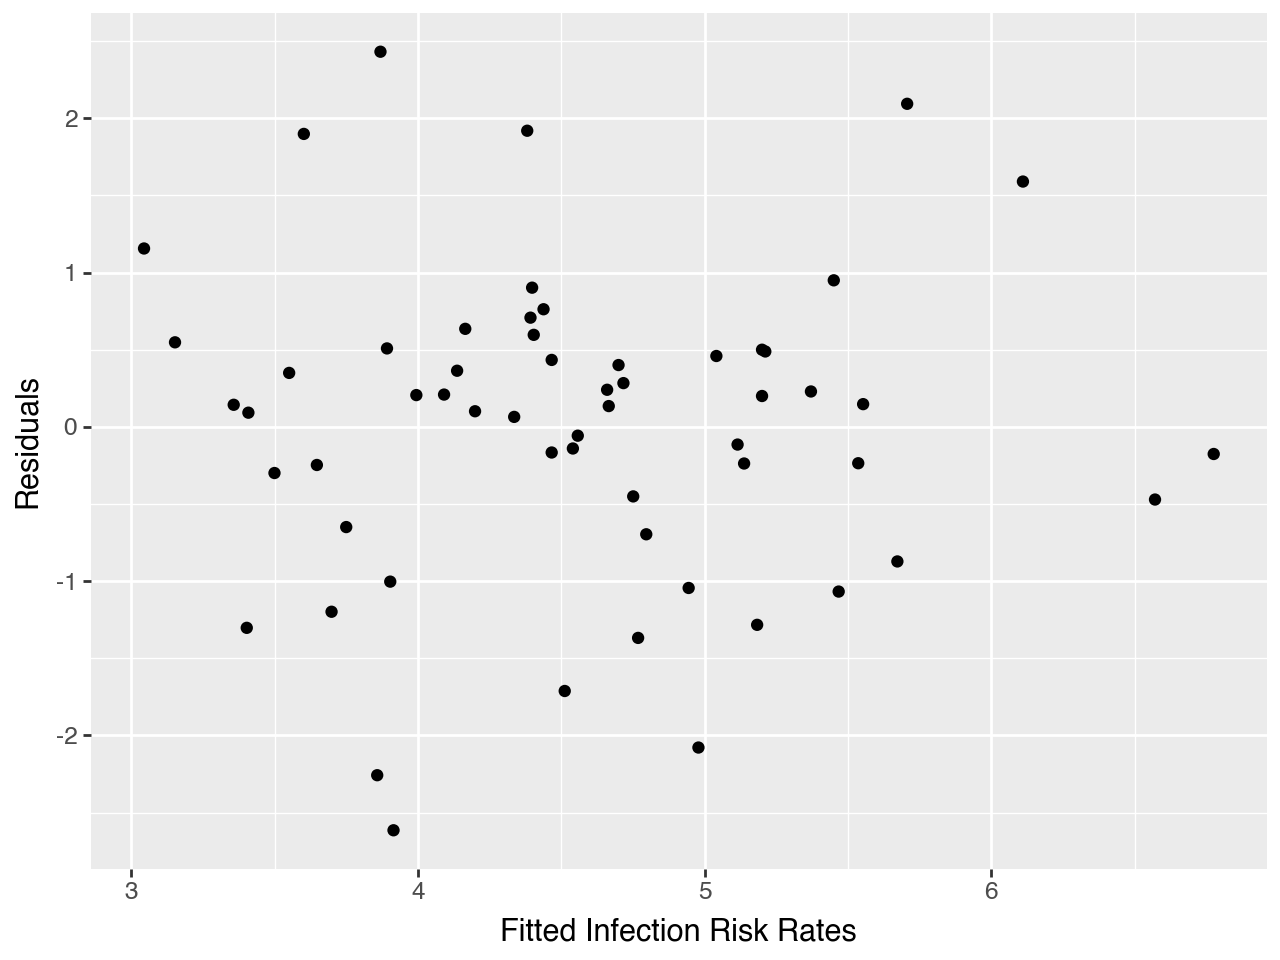

In [34]:
#Fitted Values vs. Residuals
infections_reg.loc[:, 'Predicted'] = model.fittedvalues
infections_reg.loc[:, 'Residuals'] = model.resid

plot_inf_resid = (
    ggplot(infections_reg, aes(x='Predicted', y='Residuals')) +
    geom_point() +
    labs( x='Fitted Infection Risk Rates', y='Residuals')
)
plot_inf_resid

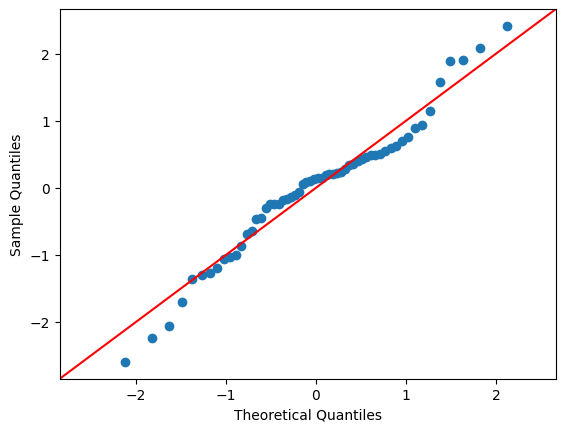

In [35]:
# qq plot
sm.qqplot(model.resid / np.std(model.resid), line = '45')

In [36]:
# Quick and dirty transformation, details later
modelnew = smf.ols('np.log(InfctRsk) ~ np.log(Stay)',infections_reg).fit()

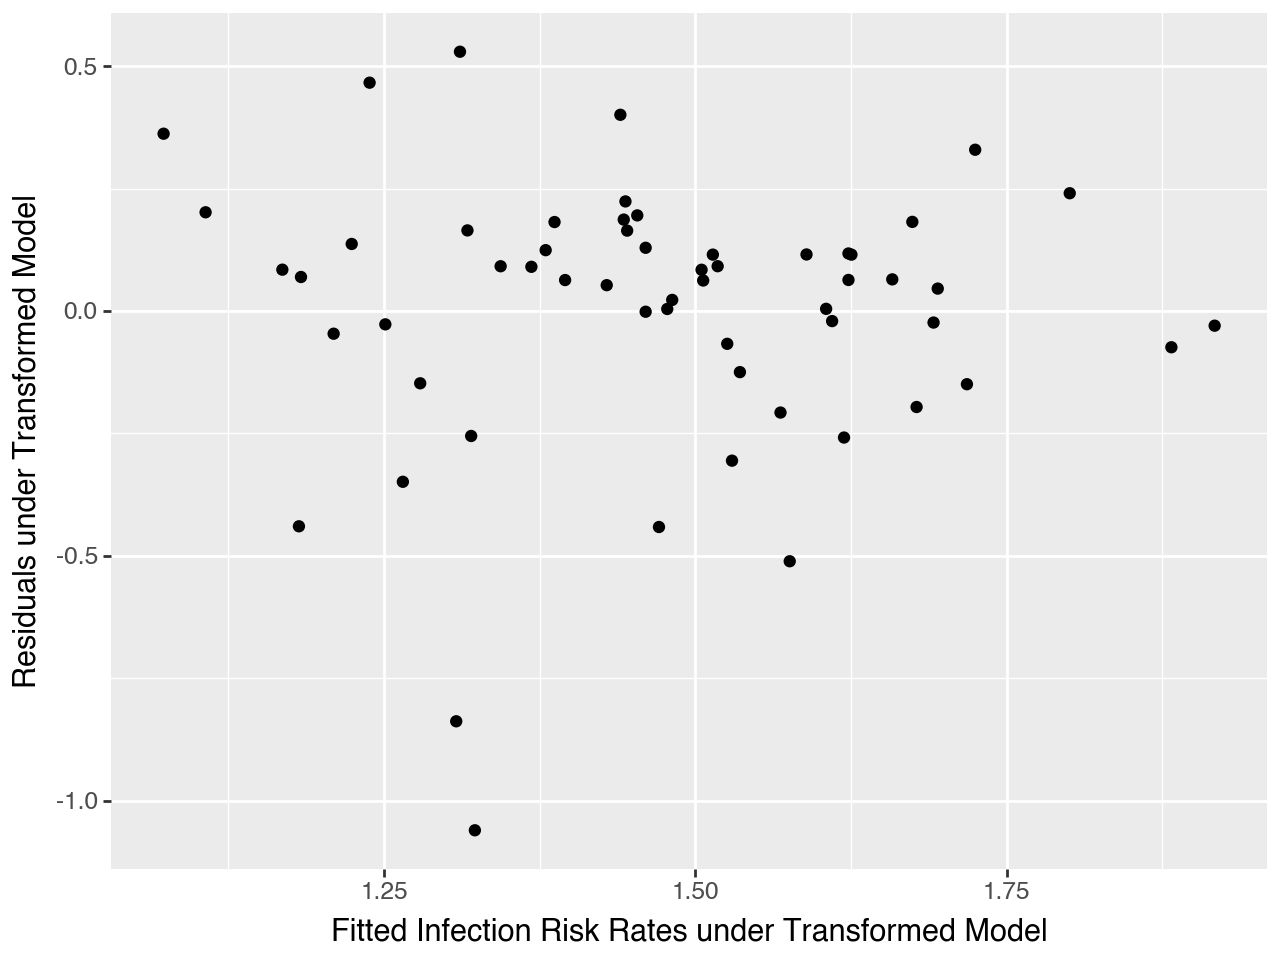

In [37]:
infections_reg.loc[:, 'Predicted_Trans'] = modelnew.fittedvalues
infections_reg.loc[:, 'Residuals_Trans'] = modelnew.resid
plot_bos_resid_trans = (
    ggplot(infections_reg, aes(x='Predicted_Trans', y='Residuals_Trans')) +
    geom_point() +
    labs( x='Fitted Infection Risk Rates under Transformed Model', y='Residuals under Transformed Model')
)
plot_bos_resid_trans

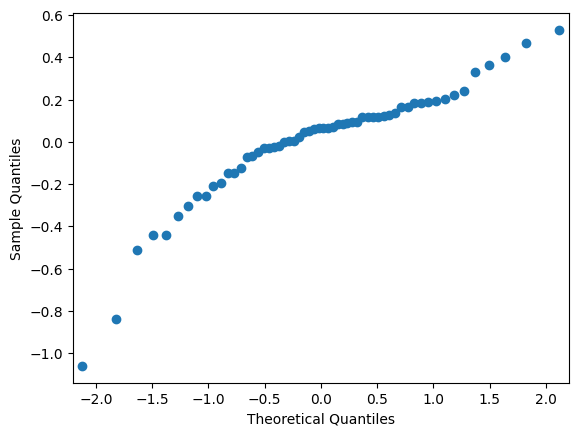

In [38]:
# qq plot
sm.qqplot(modelnew.resid)

In [39]:
# 1. The fitted value when x = 32
beta_hat = model.params

def yhat(x):
    return beta_hat[0] + beta_hat[1] * x

In [40]:
# 2. Critical value
alpha = 0.05
n = len(infections_reg)
crit = stats.t.ppf(1 - alpha/2, df=n-2)

In [41]:
# 3. Estimated standard error of E(Y|X = x)
sigma2hat = sum(model.resid**2) / (n - 2)
sigmahat = np.sqrt(sigma2hat)
x_values = infections_reg['Stay']
xbar = np.mean(x_values)
SSX = sum((x_values - xbar)**2)

def seyhat(x):
    return sigmahat * np.sqrt(1/n + (x - xbar)**2 / SSX)

In [42]:
# 95% CI for the mean infection risk rate when average stay is 32 days.
ci = yhat(x=32) + np.array([-1, 1]) * crit * seyhat(x=32)
print(f"95% CI: ", ci)


# 95% PI for a new patient with 32 days stay
se_pred = sigmahat * np.sqrt(1 + 1/n + (32 - xbar)**2 / SSX)
pi = yhat(x=32) + np.array([-1, 1]) * crit * se_pred
print(f"95% PI: ", pi)

95% CI:  [12.89452279 21.19329248]
95% PI:  [12.41472629 21.67308899]


/var/folders/8s/b3g9yw6125n1scdnf7737s_c0000gn/T/ipykernel_7108/1737636979.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


## 1.

1\. (a) From the scatterplot, there appears to be a slight linear relationship between Stay and InfctRsk based on the slight upward trend of the datapoints, and this relationship appears to be positive as well, because as Stay increases, so too does InfctRsk.\
\
1\. (b) The equation of the fitted regression line is $\hat{y}_i = -1.15981903 + 0.56886646 x_i$ or $\widehat{InfctRsk}_i = -1.15981903 + 0.56886646 * Stay_i$\
\
1\. (c) The test statistic is 6.041, and the P value is 0.000, as calculated using the OLS Regression Results. This means that Stay is a significant predictor of InfctRsk, and this can also be seen in the 95% Confidence Interval limits, where 0 is not included in the values.\
\
1\. (d) $$\hat{\beta}_1 \pm t^* \cdot SE(\hat{\beta}_1)$$ where $\hat{beta}_1 = 0.56886646$, $t^* = 6.041$, and $SE = 0.094$
$$ =0.56886646 \pm 6.041 \cdot 0.094(0.56886646)$$
$$ =0.56886646 \pm 0.3230330948 $$
$$=[0.2458333652,\ 0.8918995548]$$
1\. (d) This matches with the interval of [0.380, 0.757], though the difference can most likely be attributed to rounding and decimal values.\
\
1\. (e) After running ANOVA, the test statistic is 36.496522, and the p-value is 1.302453e-07. Since the p-value is extremely low and the test statistics is much larger, we can reject the null hypothesis and conclude that Stay is a significant predictor of InfctRsk.\
\
1\. (f)$$ t^2 = 6.041^2 \approx 36.49 $$ This matches with the F-statistic generated by ANOVA which was 36.496522. The p-values are also approximately the same, where the p-value from the t-statistic was 0.000, and the p-value generated by ANOVA was 1.302453e-07.\
\
1\. (g) The value of $R^2$ is 0.395. This suggests that the model explains a moderate fraction of the variance in the data.\
\
1\. (h) The predicted infection risk for a hospital with an average stay length of 32 days is 17.04390764.

## 2.

2\. (a) This assumption appears reasonably valid as the black regression line shows a clear positive linear trend, and the data points generally follow this linear pattern without deviating away too much. Additionally, The R² value of 0.3946 indicates a moderate linear relationship and that the data moderately fits the model.\
\
2\. (b) This assumption is questionable because looking at the residuals near the middle of the line, there is a huge increase in the spread of residuals for some as the fitted values increase whereas some others residuals are much smaller (i.e. closer to the regression line). This suggests that the variance is not completely constant across all fitted values.\
\
2\. (c) This assumption is valid. Looking at the fitted values vs residuals displays shows residuals that appear to be randomly scattered around zero with any clear or obvious patterns. The residuals seem to be oriented around the horizontal line at y=0 with no clear trends visible that would otherwise indicate dependence between observations.\
\
2\. (d) This assumption is also reasonably valid as the QQ plot shows the sample quantiles plotted against theoretical quantiles from a normal distribution. The points follow the red reference line quite closely, specifically in the middle range. There's some slight deviation in the tails but can be considered to be relatively minor due sampling variation, but overall the residuals appear to be approximately normally distributed.

## 3.

3\. The 95% confidence interval for the mean infection risk when the average stay is 32 days is [12.89452279 21.19329248]. The 95% prediction interval of the infection risk when for a new patient who would stay 32 days is [12.41472629 21.67308899].